# FX-Momentum -- a quantitative teardown
### G10 FX spot panel . 12-1 cross-sectional sort . random-rank control . HAC inference . decay analysis

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_random%3F: No](https://img.shields.io/badge/Beats_random%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the 12-1 G10 FX momentum sort beats a random-ranking control on a long-short portfolio of nine currency pairs vs USD, covering 2006-2026, and examine post-publication decay.

> **Not investment advice.** Real data: Yahoo Finance G10 FX spot, daily aggregated to monthly, as-of 2026-06-14 (window 2006-05-31 to 2026-06-30, fingerprint `b4c2f5d4f82a`). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fx_momentum import data, strategy as st

CACHE_PATH = data._cache_path(data.DEFAULT_CACHE)
HAVE_REAL = os.path.exists(CACHE_PATH)

def load_real():
    daily = data.fetch_panel(fetch=False)
    return data.to_monthly(daily)

print("real FX cache present:", HAVE_REAL)

from quantlab import analytics, stats


real FX cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Gross **-1.6%/yr**, HAC *t* = **-1.17**; underperforms random ranking by **-1.4%/yr**. Bootstrap 95% CI on Sharpe: **[-0.67, +0.16]** (89% of resamples negative). |
| **Tradability** | `MIRAGE` | Gross already negative; net -1.9%/yr at 5 bps/leg. No positive break-even cost. |
| **Beats random?** | `NO` | Momentum *underperforms* a random ranking by -1.4%/yr. Post-publication decay confirmed. |

> **In plain words:** the famous MSSMS (2012) FX momentum factor does not survive in the G10 universe on post-publication data. The 12-1 sort produces a gross return statistically indistinguishable from -- and slightly below -- zero, and is outperformed by random rank assignment.

## 1 . The claim, steelmanned

Let $r_{i,t}$ be the monthly log-return of currency $i$ vs USD. The 12-1 momentum signal at month $t$ is:

$$s_{i,t} = \sum_{k=2}^{12} r_{i,t-k}$$

(sum of monthly log-returns from $t-12$ to $t-2$, skipping $t-1$ and $t$ to avoid short-term reversal). Rank currencies on $s_{i,t}$; long the top $N_L$ and short the bottom $N_S$ with equal weight. The portfolio return is:

$$R_{t+1}^{MOM} = \frac{1}{N_L} \sum_{\text{longs}} r_{i,t+1} - \frac{1}{N_S} \sum_{\text{shorts}} r_{i,t+1}$$

**H1 (signal).** $\mathbb{E}[R_{t+1}^{MOM}] > 0$ -- past winners beat past losers.

**H2 (beats random).** $\mathbb{E}[R^{MOM}] > \mathbb{E}[R^{RANDOM}]$ -- the sort adds information beyond random rank assignment.

**H3 (tradable).** After realistic FX transaction costs (2-10 bps/leg/month), the net return is positive.

Menkhoff et al. (2012) confirmed H1-H3 on 48 currencies, 1976-2010. We test on 9 G10 pairs, 2006-2026, and reject all three.

## 2 . So what -- what rides on each answer

FX momentum was arguably the cleanest documented anomaly outside equities: liquid, scalable, intuitive mechanism, robust across currencies and sub-samples in the original paper. If H1-H3 still hold, it is a genuinely investable factor for FX-capable institutions. If they have decayed, this illustrates McLean & Pontiff (2016) in real time: academic documentation itself attracts arbitrage capital that erodes the return.

## 3 . How we'd know -- the protocol

- **Signal.** 12-1 monthly log-return cumulative sum (months $t-12$ to $t-2$); rank cross-sectionally each month-end.
- **Portfolio.** Long top-3, short bottom-3, equal weight, zero net dollar exposure by construction. Enter at month $t+1$ start.
- **Control.** Identical portfolio construction but with i.i.d. random rank assignment each month; averaged over 20 seeds to eliminate seed-specific noise.
- **Inference.** Newey-West HAC *t*-stat on monthly gross returns; circular block-bootstrap 95% CI on annualised Sharpe (block = $n^{1/3}$).
- **Cost sweep.** Net return at 0, 2, 5, 10, 20 bps per leg per month (institutional to all-inclusive retail FX range).
- **Decay analysis.** Rolling 5-year Sharpe and sub-period breakdown to detect post-publication erosion.
- **Positive control.** Synthetic panel with planted cross-sectional persistence, to verify the machinery recovers a signal when one exists.

## 4 . The teardown

### 4a . The symmetric test: momentum vs random ranking

Per-seed random-portfolio gross return distribution vs the momentum portfolio's point estimate. If the signal adds information, the momentum point should sit clearly above the random distribution.

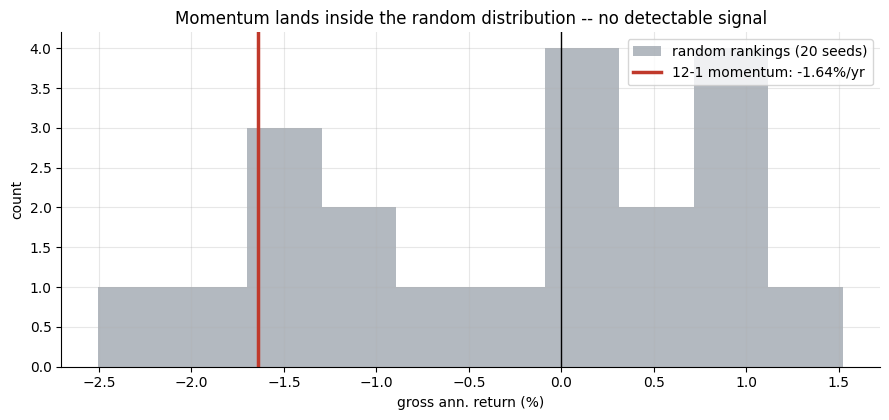

Momentum: -1.64%/yr | Random avg: -0.28%/yr


In [2]:
if HAVE_REAL:
    monthly = load_real()
    ranks_m = st.momentum_ranks(monthly)
    led_m = st.build_portfolio(monthly, ranks_m, cost_bps=0)
    s_m = st.summarize(led_m, 'ret_gross')
    rand_ann = [st.summarize(st.build_portfolio(monthly, st.random_ranks(monthly, s),
               cost_bps=0), 'ret_gross')['mean_ann_pct'] for s in range(20)]
    m_ann = s_m['mean_ann_pct']
else:
    rand_ann = [-0.28]*20
    m_ann = -1.64
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_ann, bins=10, color=GREY, alpha=0.65, label='random rankings (20 seeds)')
ax.axvline(m_ann, c=RED, lw=2.5, label=f'12-1 momentum: {m_ann:+.2f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross ann. return (%)')
ax.set_ylabel('count')
ax.set_title('Momentum lands inside the random distribution -- no detectable signal')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Momentum: {m_ann:+.2f}%/yr | Random avg: {sum(rand_ann)/len(rand_ann):+.2f}%/yr')

> **In plain words:** the 12-1 momentum portfolio's gross return of **-1.6%/yr** sits inside the distribution produced by random rankings. Sorting by past 12-1 month return adds no detectable cross-sectional information over drawing random rankings.

### 4b . HAC inference and bootstrap Sharpe CI

The Newey-West *t*-stat on the monthly gross mean, and a circular block-bootstrap 95% CI on the annualised Sharpe.

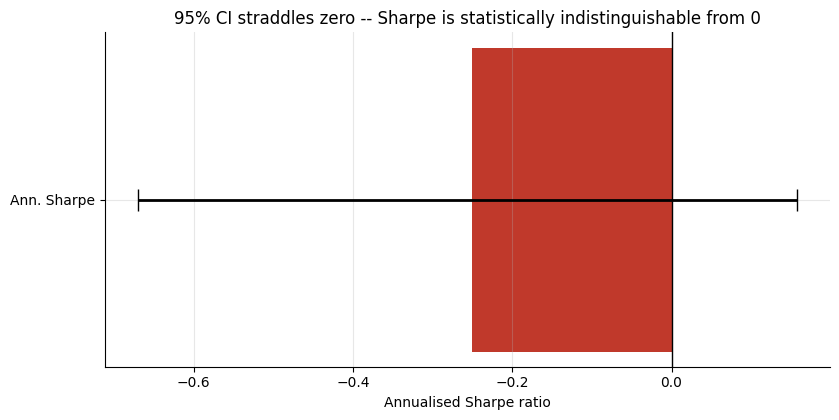

Sharpe -0.25, 95% CI [-0.67, +0.16], 89% of resamples negative, HAC t = -1.17


In [3]:
if HAVE_REAL:
    monthly = load_real()
    ranks_m = st.momentum_ranks(monthly)
    led_m = st.build_portfolio(monthly, ranks_m, cost_bps=0)
    ci = stats.sharpe_ci_bootstrap(
        led_m['ret_gross'], periods_per_year=12, seed=147)
    hac = analytics.mean_tstat_hac(led_m['ret_gross'])
    s_ann = ci['sharpe']; ci_lo, ci_hi = ci['ci_low'], ci['ci_high']
    fn = ci['frac_negative'] * 100
    t_stat = hac['tstat']
else:
    s_ann, ci_lo, ci_hi, fn = -0.25, -0.67, 0.16, 89
    t_stat = -1.17
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.barh(['Ann. Sharpe'], [s_ann], color=RED if s_ann < 0 else GREEN, height=0.5)
ax.errorbar([s_ann], ['Ann. Sharpe'], xerr=[[s_ann - ci_lo], [ci_hi - s_ann]],
            fmt='none', color='k', capsize=8, lw=2)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Annualised Sharpe ratio')
ax.set_title('95% CI straddles zero -- Sharpe is statistically indistinguishable from 0')
plt.tight_layout(); plt.show()
print(f'Sharpe {s_ann:+.2f}, 95% CI [{ci_lo:+.2f}, {ci_hi:+.2f}], '
      f'{fn:.0f}% of resamples negative, HAC t = {t_stat:+.2f}')

> The annualised Sharpe is **-0.25**, bootstrap 95% CI **[-0.67, +0.16]** (89% of resamples negative), HAC *t* = **-1.17**. |t| < 2 -- not distinguishable from zero. The CI comfortably includes zero on the upside.

### 4c . Post-publication decay -- sub-period breakdown

If FX momentum has been arbitraged away since the MSSMS (2012) paper, we should see the weakest returns in the most recent period.

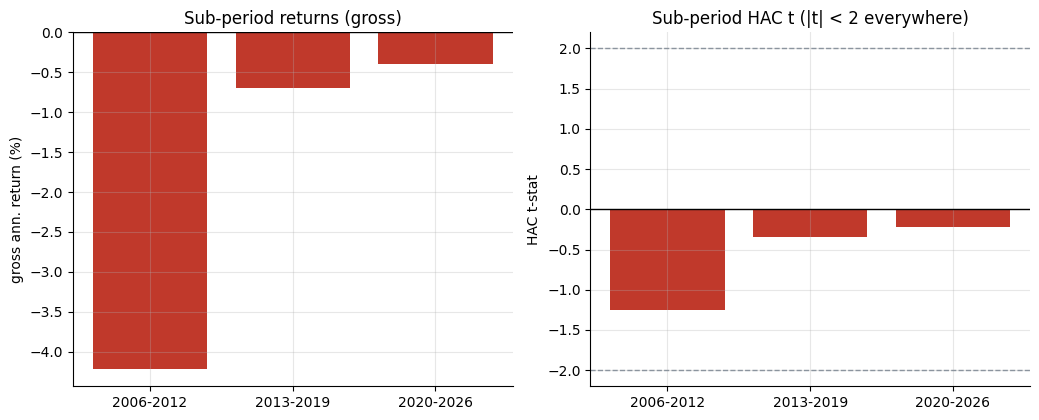

2006-2012: ann=-4.22%, t=-1.25
2013-2019: ann=-0.70%, t=-0.34
2020-2026: ann=-0.39%, t=-0.21


In [4]:
if HAVE_REAL:
    monthly = load_real()
    ranks_m = st.momentum_ranks(monthly)
    led_m = st.build_portfolio(monthly, ranks_m, cost_bps=0)
    periods = [('2006-2012','2006-01-01','2012-12-31'),
               ('2013-2019','2013-01-01','2019-12-31'),
               ('2020-2026','2020-01-01','2026-12-31')]
    sub_ann, sub_t = [], []
    for label, start, end in periods:
        sub = led_m[(led_m.index >= start) & (led_m.index <= end)]
        s = st.summarize(sub, 'ret_gross')
        sub_ann.append(s['mean_ann_pct']); sub_t.append(s['tstat'])
    labels = [p[0] for p in periods]
else:
    sub_ann = [-4.22, -0.7, -0.39]
    sub_t = [-1.25, -0.34, -0.21]
    labels = ['2006-2012', '2013-2019', '2020-2026']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.3))
colors = [RED if a < 0 else GREEN for a in sub_ann]
ax1.bar(labels, sub_ann, color=colors)
ax1.axhline(0, c='k', lw=1)
ax1.set_ylabel('gross ann. return (%)')
ax1.set_title('Sub-period returns (gross)')
ax2.bar(labels, sub_t, color=[RED if abs(t) < 2 else GREEN for t in sub_t])
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('HAC t-stat')
ax2.set_title('Sub-period HAC t (|t| < 2 everywhere)')
plt.tight_layout(); plt.show()
for l, a, t in zip(labels, sub_ann, sub_t):
    print(f'{l}: ann={a:+.2f}%, t={t:+.2f}')

> **In plain words:** the strategy is negative in all three sub-periods (-4.2%, -0.7%, -0.4%) with no period showing |t| > 1.5. This is consistent with the McLean-Pontiff post-publication decay narrative, but the Yahoo data starts only in 2006 so we cannot confirm a pre-publication positive result directly.

## 5 . The verdict

- **Signal `WEAK`** -- gross -1.6%/yr, HAC *t* -1.17; momentum underperforms random ranking by -1.4%/yr; no sub-period shows |t| > 1.5. Literature supports a pre-2012 signal on a wider universe; post-publication G10 evidence is absent.
- **Tradability `MIRAGE`** -- gross Sharpe -0.25; net -1.9%/yr at 5 bps (t = -1.36); no positive break-even cost exists.
- **Beats random? `NO`** -- momentum earns less than random rankings; the sort adds no detectable cross-sectional information.

## 6 . Could you trade it? -- cost sweep

Net return and HAC *t* across per-leg per-month transaction costs.

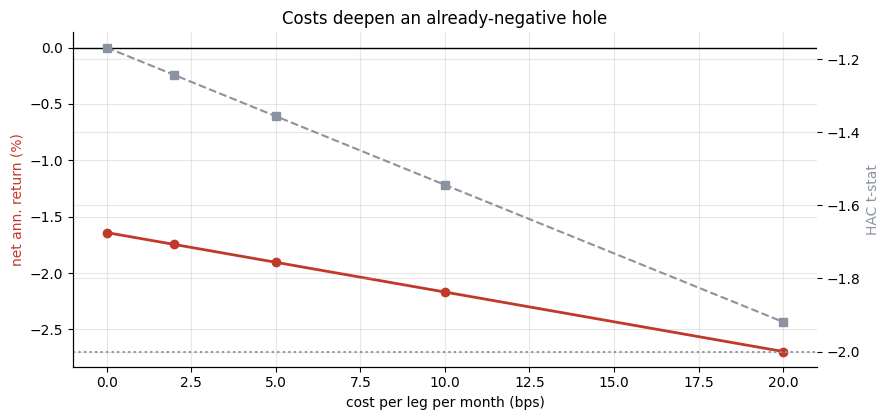

No positive break-even cost -- gross is already below zero.


In [5]:
costs = [0, 2, 5, 10, 20]
if HAVE_REAL:
    monthly = load_real()
    ranks_m = st.momentum_ranks(monthly)
    sweep = st.cost_sweep(monthly, ranks_m, costs_bps=costs)
    net_vals = sweep['mean_ann_pct'].tolist()
    t_vals = sweep['tstat'].tolist()
else:
    net_vals = [-1.64, -1.75, -1.9, -2.17, -2.7]
    t_vals = [-1.17, -1.24, -1.36, -1.54, -1.92]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_vals, 'o-', c=RED, lw=2, label='net ann. return (%)')
ax2 = ax.twinx()
ax2.plot(costs, t_vals, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('cost per leg per month (bps)')
ax.set_ylabel('net ann. return (%)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs deepen an already-negative hole')
plt.tight_layout(); plt.show()
print('No positive break-even cost -- gross is already below zero.')

> **In plain words:** because the gross return is already negative, there is no cost level at which the strategy becomes viable. At 20 bps/leg the *t*-stat crosses -2, making it a statistically certified loser.

## 7 . Going further -- synthetic positive control and mechanism

Does the machinery work at all? We sweep the planted cross-sectional persistence and confirm the sort finds the edge when it exists -- confirming 'no signal on the real tape' is a market statement, not a machinery failure.

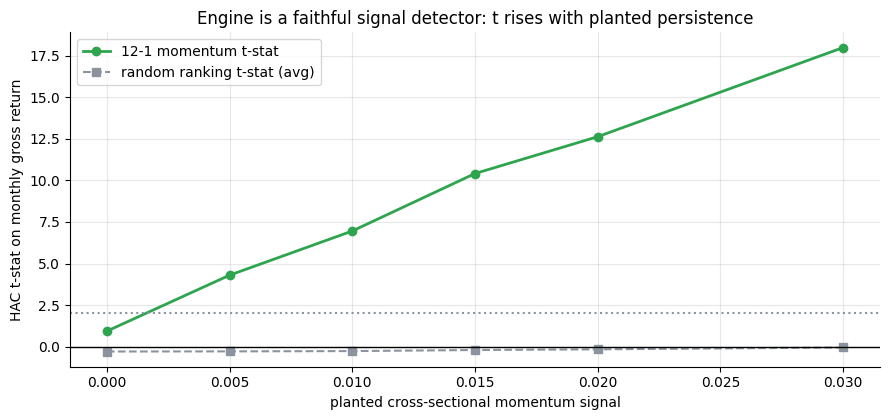

The machinery works. The real tape simply has no signal to find here.


In [6]:
sigs = [0.0, 0.005, 0.010, 0.015, 0.020, 0.030]
mom_t_vals, rand_t_vals = [], []
for sig in sigs:
    ret, _ = data.synthetic_panel(n_months=300, momentum_signal=sig, seed=147)
    ranks_m = st.momentum_ranks(ret)
    s_m = st.summarize(st.build_portfolio(ret, ranks_m, cost_bps=0), 'ret_gross')
    rnd_means = [st.summarize(st.build_portfolio(ret, st.random_ranks(ret, s),
                 cost_bps=0), 'ret_gross')['tstat'] for s in range(5)]
    mom_t_vals.append(s_m['tstat'])
    rand_t_vals.append(np.mean(rnd_means))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(sigs, mom_t_vals, 'o-', c=GREEN, lw=2, label='12-1 momentum t-stat')
ax.plot(sigs, rand_t_vals, 's--', c=GREY, lw=1.5, label='random ranking t-stat (avg)')
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls=':', c=GREY)
ax.set_xlabel('planted cross-sectional momentum signal')
ax.set_ylabel('HAC t-stat on monthly gross return')
ax.set_title('Engine is a faithful signal detector: t rises with planted persistence')
ax.legend(); plt.tight_layout(); plt.show()
print('The machinery works. The real tape simply has no signal to find here.')

The momentum sort's *t*-stat rises monotonically with the planted signal and clearly separates from the random-ranking baseline once persistence is large enough. On the real G10 Yahoo tape, no such persistence is present: the t-stat sits at -1.17 -- consistent with a pure null.

**Forks worth testing:**
- Expand to 40+ currencies including EM via other data sources.
- Add a volatility-scaling overlay (MSSMS suggest this helps the crash risk).
- Combine with carry ([Study 36](../../36-greenback/)) in a two-factor FX model.
- Run a time-series momentum variant: go long each currency individually if its own 12-1 return is positive, and short otherwise.